# Production Summary (Year-to-Date)


This query aims to summarise the list of equipment built by a manufacturing shop from the beginning of the year to the current date. We want every item listed out and information regarding its status in the shop floor (is it Ready to build? Work in Progress? Shipped?). We want in the first few rows the sum of all the equipment built and sorted into categories.

# Section 1: Selecting the columns

Management is interested in the roll up summary being in the top rows of the result table. They are also interested to have data on hand that will tell them which customers, category of items, when the work orders were closed, shipping reference, quantities and status of equipment was built, among other things. This will be below the roll-up summary rows. The format shall be as follows:

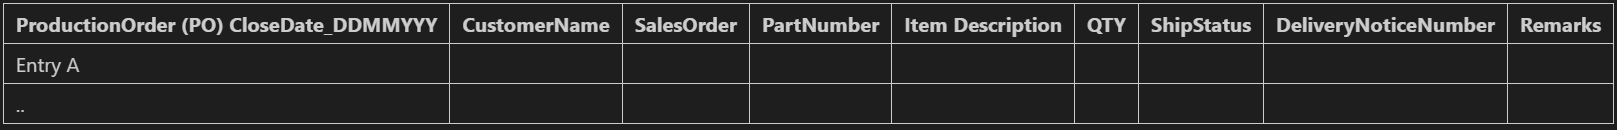


# Section 2. Selecting the Tables and Columns 

In SAP B1, a new item to plan for proudction requires creating a new production order. Referring to the Erpref.com, we find that the table for this on SAP is called OWOR. This table does not have the full description of the part, so we will join another table OITM to obtain this. The name of the customer is also not on the OWOR Table, so we will need to join it with the Sales Order table ORDR to get it. We can also go on SAP and turn on Ctrl+Shift+I to get the column names of the field that we will use for the query.

In [ ]:
SELECT 
	T11.DocNum							AS ProdRecepitNo,
	CONVERT(varchar,T11.DocDate, 23)	AS POCloseDate,
	T7.CardName							AS CustomerName,									
	T8.Project							AS SalesOrderNo,
	T7.U_REF10							AS QuoteNo,
	T7.NumAtCard						AS PurchaseOrderNo,
	T1.ItemCode							AS part_num,								
	T1.Comments							AS part_description,
	CAST(T8.Quantity AS INT)			AS qty,
	T7.U_OS 							AS SAP_ship_status,
	T4.ItmsGrpCod						AS item_group,
	'1'									AS row_type
		
	FROM IGN1 T8 
		LEFT JOIN OIGN T11 ON T8.DocEntry = T11.DocEntry	-- Assigned T11 alias for OIGN
		LEFT JOIN OWOR T1 ON T8.BaseRef = T1.DocNum			-- Assigned T1 alias for OWOR
		LEFT JOIN ORDR T7 ON  T1.OriginNum = T7.DocNum		-- Assigned T7 alias for ORDR
		INNER JOIN OITM T4 ON T1.ItemCode = T4.ItemCode 	-- Assigned T4 alias for OITM

	WHERE
		YEAR(T11.DocDate) = YEAR(GETDATE())		-- Only include products built in the CURRENT year.
		AND (T4.ItmsGrpCod = 143			    -- Item group codes for pump 
		OR T4.ItmsGrpCod = 190)			        -- Skid assm
		AND T11.Comments IS NULL				-- THIS IS ADDED TO ENSURE ANY REBUILD/CORRECTIONS/MISTAKES PRODUCTION ORDERS ARE NOT COUNTED!
		AND (T1.Type != 'D' OR T1.Status != 'C' 
		OR T1.Comments NOT LIKE '%replaces%'
		OR T11.Comments NOT LIKE '%wrong%')

# Section 3: Setting Up Common Table Expression (CTE) for the individual Equipment Rows

To get the summary rows on the top and indivudal entries below it, we wil utilise CTE to achieve this. A sub query for the production receipt of equipment (productions with closing transactions on SAP) will be generated from this subquery.

In [ ]:
%%sql

WITH 
production_receipt 
AS(

-- INSERT THE SUB QUERY ABOVE HERE

)


...

# Section 4. Common Table Expression for the Summary Rows

We wil utilise CTE and call it summary rows to SUM the entries in production_receipt and create another table that will be joined in the final result.

In [ ]:
...
,
summaryrows		-- CTE for Summation Rows that will be unioned 
AS (
	SELECT 											-- Placeholders added to match number of columns of the main entry CTE
	'-'					AS POCloseDate_yyyymmdd,					-- 1.
	'-'					as ProdReceiptNo,
	'-'					AS CustomerName,							-- 2.
	'-'					AS SalesOrderNo,							-- 3.
	'-'					AS QuoteNo,
	'-'					AS PurchaseOrderNo,
	'-'					AS part_num,								-- 4.
	CONCAT(year(POCloseDate), ' ',
	CASE 
		WHEN item_group = 143 THEN 'Pumps Built' 
		WHEN item_group = 190 THEN 'Skids Assembled' END,
	' total ')			AS part_description,						-- 5.
	SUM(qty)			AS qty,										-- 6.
	SAP_ship_status		AS SAP_ship_status,
	item_group			AS item_group,								
	'2'					AS row_type									

	FROM production_receipt
	
	GROUP BY item_group, SAP_ship_status, year(POCloseDate)--,part_num
) 
...

# Section 5: Generate Main Query to UNION the CTE's and generate a merged result

We run the sql file in SSMS (SQL Server Management Studio) in our local, non-live SQL server to obtain the results.

In [ ]:
...
SELECT * FROM production_receipt
UNION ALL
SELECT *  FROM summaryrows

order by row_type DESC, SAP_ship_status DESC, SalesOrderNo desc, POCloseDate desc, part_description desc, item_group, ProdRecepitNo DESC 
...

# Section 6: Review Results

...
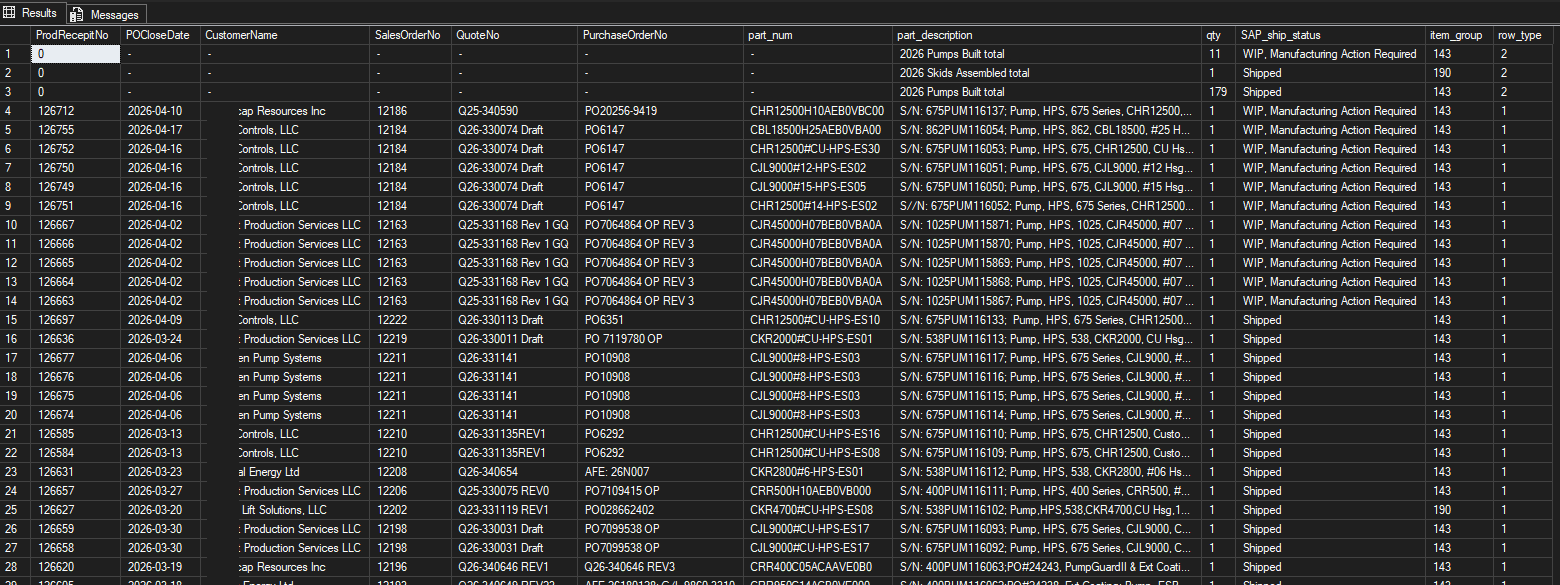

# Section 7: Export to a folder for peer review as CSV/XLSX and PDF, replacing the old files

The following PowerShell script is created to merge any new rows/entries to the working excel file.